# Structural Equation Modeling
**Tongkyu Kim** — World Bank Group, Korea Green Growth Trust Fund

Survey: *AI Use by Young Adults* (N = 117)

---

## Setup

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler
from scipy import stats
from semopy import Model, Optimizer
from semopy.stats import gather_statistics
import warnings
warnings.filterwarnings('ignore')

DATE = datetime.now().strftime('%Y%m%d')

In [2]:
df = pd.read_excel('../src/raw/wbg_ai.xlsx')
print(f'N = {len(df)},  variables = {df.shape[1]},  missing = {df.isnull().sum().sum()}')
df.head()

N = 117,  variables = 35,  missing = 0


,age_group,gender,field,svc_chatgpt,svc_claude,svc_gemini,svc_perplexity,svc_other,svc_n,freq,...,beh_priv,why_prefer,view_sent,view_reason,beh_prompt,beh_env_avoid,beh_advise,beh_transp,prompt_type,percep_change
0,1,2,2,0,1,0,0,0,1,3,...,1,4,3,2,1,1,1,2,6,3
1,2,1,2,0,1,1,0,0,2,3,...,5,6,4,5,4,1,1,5,6,3
2,2,1,2,1,1,1,1,0,4,3,...,1,6,4,5,5,5,1,1,6,3
3,1,2,1,1,1,0,0,0,2,2,...,2,3,4,1,4,3,1,4,4,3
4,2,2,1,1,1,0,0,1,3,3,...,5,4,3,2,4,3,1,5,6,3


---
## 1. Descriptive Analysis

### 1a. Demographic Profile

In [3]:
LABELS = {
    'age_group':   {1: '20–24', 2: '25–29', 3: '30–34', 4: '35–39'},
    'gender':      {1: 'Male', 2: 'Female'},
    'field':       {1: 'STEM', 2: 'Social Sciences', 3: 'Arts & Humanities', 4: 'Other'},
    'freq':        {0: 'None', 1: '1–2/day', 2: '3–5/day', 3: '6+/day'},
    'purpose':     {1: 'Research/Productivity/Learning', 2: 'Conversation/Advice',
                    3: 'Creative', 4: 'Decision-making', 5: 'Writing/Editing', 6: 'Other/Multiple'},
    'concern':     {1: 'Over-reliance/Skill loss', 2: 'Harmful use/Misuse', 3: 'Data accuracy',
                    4: 'Privacy/Security', 5: 'Environmental impact', 6: 'Market monopoly', 7: 'Multiple/Other'},
    'why_prefer':  {1: 'Familiarity/Default', 2: 'Convenience', 3: 'Quality/Accuracy',
                    4: 'Task-specific fit', 5: 'Cost/Free access', 6: 'Multiple reasons'},
    'view_sent':   {1: 'Very negative', 2: 'Negative', 3: 'Mixed/Neutral', 4: 'Positive', 5: 'Very positive'},
    'view_reason': {1: 'Efficiency/Time-saving', 2: 'Information access', 3: 'Concerns/Risks',
                    4: 'Convenience', 5: 'Mixed/Other'},
    'prompt_type': {1: 'None/No response', 2: 'Academic/Study', 3: 'Creative',
                    4: 'Personal/Self-reflective', 5: 'Research/Professional', 6: 'Other'},
    'percep_change': {1: 'More negative', 2: 'More cautious/aware', 3: 'No meaningful change',
                      4: 'More positive', 5: 'Much more positive / now essential'},
}

def freq_table(col):
    vc = df[col].value_counts().sort_index()
    pct = (vc / len(df) * 100).round(1)
    tbl = pd.DataFrame({'n': vc, '%': pct})
    if col in LABELS:
        tbl.index = tbl.index.map(LABELS[col])
    tbl.index.name = col
    return tbl

for col in ['age_group', 'gender', 'field']:
    print(freq_table(col).to_string(), '\n')

            n     %
age_group          
20–24      16  13.7
25–29      87  74.4
30–34      11   9.4
35–39       3   2.6 

         n     %
gender          
Male    35  29.9
Female  82  70.1 

                    n     %
field                      
STEM               59  50.4
Social Sciences    26  22.2
Arts & Humanities  12  10.3
Other              20  17.1 



### 1b. AI Service Usage

In [4]:
svc_cols = ['svc_chatgpt', 'svc_claude', 'svc_gemini', 'svc_perplexity', 'svc_other']
svc_summary = pd.DataFrame({
    'Service':   ['ChatGPT', 'Claude', 'Gemini', 'Perplexity', 'Other'],
    'n_users':   [df[c].sum() for c in svc_cols],
    'pct_users': [(df[c].mean() * 100).round(1) for c in svc_cols],
}).sort_values('n_users', ascending=False).reset_index(drop=True)

print(svc_summary.to_string(index=False))
print(f'\nAvg services per respondent:  mean = {df["svc_n"].mean():.2f},  SD = {df["svc_n"].std():.2f}')
print('\nServices used per respondent (distribution):')
print(df['svc_n'].value_counts().sort_index().to_string())

   Service  n_users  pct_users
   ChatGPT       76       65.0
    Gemini       70       59.8
    Claude       46       39.3
Perplexity       15       12.8
     Other        8        6.8

Avg services per respondent:  mean = 1.84,  SD = 0.98

Services used per respondent (distribution):
svc_n
0     2
1    53
2    31
3    25
4     5
5     1


### 1c. Usage Patterns & Attitudes

In [5]:
for col in ['freq', 'purpose', 'concern', 'why_prefer', 'view_sent', 'view_reason', 'prompt_type', 'percep_change']:
    print(freq_table(col).to_string(), '\n')

          n     %
freq             
None      4   3.4
1–2/day  30  25.6
3–5/day  14  12.0
6+/day   69  59.0 

                                 n     %
purpose                                 
Research/Productivity/Learning  99  84.6
Conversation/Advice              6   5.1
Creative                         7   6.0
Decision-making                  3   2.6
Writing/Editing                  2   1.7 

                           n     %
concern                           
Over-reliance/Skill loss  54  46.2
Harmful use/Misuse        36  30.8
Data accuracy             25  21.4
Market monopoly            1   0.9
Multiple/Other             1   0.9 

                      n     %
why_prefer                   
Familiarity/Default   6   5.1
Convenience           8   6.8
Quality/Accuracy      7   6.0
Task-specific fit    15  12.8
Cost/Free access      8   6.8
Multiple reasons     73  62.4 

                n     %
view_sent              
Negative        2   1.7
Mixed/Neutral  35  29.9
Positive       7

### 1d. Likert Item Descriptives

All substantive scale items (1–5). `att_skill_worry` shown in original coding here; it is reverse-scored in all analyses.

In [6]:
ITEM_LABELS = {
    'att_pos':          'I am positive about AI use',
    'att_easy':         'AI makes my life easier',
    'att_skill_worry':  'Worry AI reduces my skills/independence (R)',
    'att_anxiety':      'Anxious when I cannot use AI',
    'aw_error':         'Aware: AI can produce errors/bias/fabrication',
    'aw_ethics':        'Aware: AI raises ethics/accountability issues',
    'aw_privacy':       'Aware: AI poses privacy/data security risks',
    'aw_deepfake':      'Aware: AI can be misused for deepfakes/scams',
    'aw_env_dc':        'Aware: AI data centers consume significant energy',
    'aw_env_use':       'Aware: Inefficient AI use increases energy burden',
    'beh_resp':         'Take full responsibility for AI-assisted work',
    'beh_check':        'Cross-check AI output against other sources',
    'beh_priv':         'Avoid uploading personal/confidential data',
    'beh_harmful':      'Check AI output for harmful/biased content',
    'beh_prompt':       'Write clear prompts to avoid repeated reruns',
    'beh_env_avoid':    'Avoid AI use due to energy/resource concerns',
    'beh_advise':       'Advise others about AI environmental impact',
    'beh_transp':       'Want providers to be transparent on energy use',
}

likert_cols = list(ITEM_LABELS.keys())

desc_rows = []
for col in likert_cols:
    s = df[col]
    desc_rows.append({
        'Item':     col,
        'Label':    ITEM_LABELS[col],
        'Mean':     round(s.mean(), 2),
        'SD':       round(s.std(), 2),
        'Min':      int(s.min()),
        'Max':      int(s.max()),
        'Skewness': round(s.skew(), 3),
        'Kurtosis': round(s.kurtosis(), 3),
        'pct_5':    round((s == 5).mean() * 100, 1),
    })

desc_df = pd.DataFrame(desc_rows)
desc_df

,Item,Label,Mean,SD,Min,Max,Skewness,Kurtosis,pct_5
0,att_pos,I am positive about AI use,4.25,0.85,2,5,-1.101,0.749,45.3
1,att_easy,AI makes my life easier,4.59,0.53,3,5,-0.725,-0.726,60.7
2,att_skill_worry,Worry AI reduces my skills/independence (R),3.66,1.12,1,5,-0.918,0.231,20.5
3,att_anxiety,Anxious when I cannot use AI,2.61,1.35,1,5,0.255,-1.322,7.7
4,aw_error,Aware: AI can produce errors/bias/fabrication,4.82,0.39,4,5,-1.692,0.878,82.1
5,aw_ethics,Aware: AI raises ethics/accountability issues,4.66,0.62,2,5,-2.074,4.937,71.8
6,aw_privacy,Aware: AI poses privacy/data security risks,4.56,0.67,2,5,-1.438,1.435,65.8
7,aw_deepfake,Aware: AI can be misused for deepfakes/scams,4.74,0.54,2,5,-2.379,6.387,78.6
8,aw_env_dc,Aware: AI data centers consume significant energy,4.09,1.14,1,5,-1.261,0.606,47.0
9,aw_env_use,Aware: Inefficient AI use increases energy burden,4.01,1.17,1,5,-1.033,-0.018,45.3


In [7]:
CONSTRUCTS_ALL = {
    'Attitude':          ['att_pos', 'att_easy', 'att_skill_worry', 'att_anxiety'],
    'Awareness (Worry)': ['aw_error', 'aw_ethics', 'aw_privacy', 'aw_deepfake'],
    'Awareness (Env)':   ['aw_env_dc', 'aw_env_use'],
    'Beh_Environmental': ['beh_env_avoid', 'beh_advise'],
    'Beh_Responsible':   ['beh_resp', 'beh_check', 'beh_harmful', 'beh_prompt'],
    'Excluded':          ['beh_priv', 'beh_transp'],
}

print(f'  {"Construct":<22} {"Item":<22} {"Mean":>6} {"SD":>6} {"Skew":>7} {"Kurt":>7} {"%=5":>6}')
print('  ' + '-' * 76)
for cname, items in CONSTRUCTS_ALL.items():
    for item in items:
        row = desc_df[desc_df['Item'] == item].iloc[0]
        print(f'  {cname:<22} {item:<22} {row["Mean"]:>6.2f} {row["SD"]:>6.2f} '
              f'{row["Skewness"]:>7.3f} {row["Kurtosis"]:>7.3f} {row["pct_5"]:>5.1f}%')
    print()

  Construct              Item                     Mean     SD    Skew    Kurt    %=5
  ----------------------------------------------------------------------------
  Attitude               att_pos                  4.25   0.85  -1.101   0.749  45.3%
  Attitude               att_easy                 4.59   0.53  -0.725  -0.726  60.7%
  Attitude               att_skill_worry          3.66   1.12  -0.918   0.231  20.5%
  Attitude               att_anxiety              2.61   1.35   0.255  -1.322   7.7%

  Awareness (Worry)      aw_error                 4.82   0.39  -1.692   0.878  82.1%
  Awareness (Worry)      aw_ethics                4.66   0.62  -2.074   4.937  71.8%
  Awareness (Worry)      aw_privacy               4.56   0.67  -1.438   1.435  65.8%
  Awareness (Worry)      aw_deepfake              4.74   0.54  -2.379   6.387  78.6%

  Awareness (Env)        aw_env_dc                4.09   1.14  -1.261   0.606  47.0%
  Awareness (Env)        aw_env_use               4.01   1.17  -1.033

### 1e. Inter-item Correlation Matrices by Construct

In [8]:
FINAL_CONSTRUCTS = {
    'Awareness_Worry':   ['aw_error', 'aw_ethics', 'aw_privacy', 'aw_deepfake'],
    'Awareness_Env':     ['aw_env_dc', 'aw_env_use'],
    'Attitude':          ['att_pos', 'att_easy', 'att_skill_worry'],
    'Beh_Environmental': ['beh_env_avoid', 'beh_advise'],
    'Beh_Responsible':   ['beh_resp', 'beh_check', 'beh_harmful', 'beh_prompt'],
}

for cname, items in FINAL_CONSTRUCTS.items():
    sub = df[items].copy()
    if 'att_skill_worry' in items:
        sub['att_skill_worry'] = 6 - sub['att_skill_worry']
    print(f'{cname}')
    print(sub.corr().round(3).to_string())
    print()

Awareness_Worry
             aw_error  aw_ethics  aw_privacy  aw_deepfake
aw_error        1.000      0.464       0.393        0.437
aw_ethics       0.464      1.000       0.322        0.378
aw_privacy      0.393      0.322       1.000        0.398
aw_deepfake     0.437      0.378       0.398        1.000

Awareness_Env
            aw_env_dc  aw_env_use
aw_env_dc       1.000       0.789
aw_env_use      0.789       1.000

Attitude
                 att_pos  att_easy  att_skill_worry
att_pos            1.000     0.536            0.401
att_easy           0.536     1.000            0.314
att_skill_worry    0.401     0.314            1.000

Beh_Environmental
               beh_env_avoid  beh_advise
beh_env_avoid          1.000       0.563
beh_advise             0.563       1.000

Beh_Responsible
             beh_resp  beh_check  beh_harmful  beh_prompt
beh_resp        1.000      0.327        0.390       0.179
beh_check       0.327      1.000        0.381       0.249
beh_harmful     0.390     

In [9]:
desc_df.to_csv(f'../output/tables/descriptives_{DATE}.csv', index=False)
print(f'Saved → output/tables/descriptives_{DATE}.csv')

cat_cols = ['age_group', 'gender', 'field', 'freq', 'purpose',
            'concern', 'why_prefer', 'view_sent', 'view_reason', 'prompt_type', 'percep_change']
cat_frames = []
for col in cat_cols:
    tbl = freq_table(col).reset_index()
    tbl.insert(0, 'variable', col)
    cat_frames.append(tbl)
pd.concat(cat_frames).to_csv(f'../output/tables/frequencies_{DATE}.csv', index=False)
print(f'Saved → output/tables/frequencies_{DATE}.csv')

Saved → output/tables/descriptives_20260609.csv
Saved → output/tables/frequencies_20260609.csv


---
## 2. Convergent Validity

Three complementary reliability/validity measures reported per construct:

| Measure | Formula | Threshold |
|---|---|---|
| **α** Cronbach's Alpha | Based on inter-item covariances | ≥ 0.70 |
| **CR** Composite Reliability (Dillon-Goldstein's ρc) | (Σλ)² / [(Σλ)² + Σ(1−λ²)] | ≥ 0.70 |
| **ρA** Dijkstra-Henseler's rho_A | CR × (r̄ / AVE) | ≥ 0.70 |
| **AVE** Average Variance Extracted | Σλ² / k | ≥ 0.50 |

Standardized factor loadings (λ) estimated via single-factor ML-FA per construct.

### Construct definitions

- **Awareness (Worry)**: error/bias, ethics, privacy, deepfake — `aw_error`, `aw_ethics`, `aw_privacy`, `aw_deepfake`
- **Awareness (Env)**: data-center energy, cumulative usage — `aw_env_dc`, `aw_env_use`
- **Attitude**: positive attitude, ease, skill worry (R) — `att_pos`, `att_easy`, `att_skill_worry`
- **Beh_Environmental**: avoidance, advising others — `beh_env_avoid`, `beh_advise`
- **Beh_Responsible**: responsibility, verification, harm-checking, efficient prompting — `beh_resp`, `beh_check`, `beh_harmful`, `beh_prompt`

*Excluded: `att_anxiety` (measures AI dependency, not attitude; item-total r ≈ 0.007). `beh_priv` (lowest item-total r in Beh_Responsible pool). `beh_transp` removed from Beh_Environmental — it measures a value/expectation rather than a behavior; dropping it raises α from 0.686 → 0.719 and AVE from 0.448 → 0.563.*

In [ ]:
CONSTRUCTS = {
    'Awareness_Worry':   ['aw_error', 'aw_ethics', 'aw_privacy', 'aw_deepfake'],
    'Awareness_Env':     ['aw_env_dc', 'aw_env_use'],
    'Attitude':          ['att_pos', 'att_easy', 'att_skill_worry'],
    'Beh_Environmental': ['beh_env_avoid', 'beh_advise'],
    'Beh_Responsible':   ['beh_resp', 'beh_check', 'beh_harmful', 'beh_prompt'],
}
REVERSE_ITEMS = ['att_skill_worry']

# Inner (structural) model
STRUCT_MODEL = {
    'Attitude':          ['Awareness_Worry', 'Awareness_Env'],
    'Beh_Environmental': ['Attitude'],
    'Beh_Responsible':   ['Attitude'],
}

def prep(items):
    sub = df[items].copy()
    for c in REVERSE_ITEMS:
        if c in sub.columns:
            sub[c] = 6 - sub[c]
    return sub

def cronbach_alpha(data):
    arr = np.array(data)
    n = arr.shape[1]
    if n < 2:
        return np.nan
    vt = arr.sum(axis=1).var(ddof=1)
    if vt == 0:
        return np.nan
    return (n / (n - 1)) * (1 - arr.var(axis=0, ddof=1).sum() / vt)

def compute_cr(loadings):
    "Dillon-Goldstein composite reliability from PLS outer loadings."
    sl = np.sum(loadings)
    return sl ** 2 / (sl ** 2 + np.sum(1 - loadings ** 2))

def compute_ave(loadings):
    "Average Variance Extracted from PLS outer loadings."
    return np.mean(loadings ** 2)

def compute_rho_a(loadings, R):
    "Dijkstra-Henseler rho_A."
    p = len(loadings)
    Rv = R.values.copy()
    np.fill_diagonal(Rv, 0)
    r_bar = Rv.sum() / (p * (p - 1))
    ave_lam2 = np.mean(loadings ** 2)
    cr = compute_cr(loadings)
    if ave_lam2 == 0:
        return np.nan
    return float(np.clip(cr * (r_bar / ave_lam2), 0.0, 1.0))

# ── PLS-SEM: NIPALS with centroid inner weighting (all reflective blocks) ──
def pls_nipals(constructs, struct_model, n_iter=300, tol=1e-7):
    # Centroid inner weighting, reflective outer OLS estimation.
    # Returns: lv_scores (DataFrame), outer_weights (dict), outer_loadings (dict).
    n = len(df)
    blocks = {}
    for cname, items in constructs.items():
        blocks[cname] = StandardScaler().fit_transform(prep(items))

    # Initialise: mean of standardised indicators
    lv = {}
    for cname in constructs:
        s = blocks[cname].mean(axis=1)
        std = s.std(ddof=1)
        lv[cname] = (s - s.mean()) / (std if std > 0 else 1.0)

    # Adjacency set for centroid inner step
    adj = {c: set() for c in constructs}
    for outcome, preds in struct_model.items():
        for p in preds:
            adj[outcome].add(p)
            adj[p].add(outcome)

    outer_w = {}
    for it in range(n_iter):
        old = {c: lv[c].copy() for c in constructs}

        # Inner step: centroid weighting
        inner = {}
        for c in constructs:
            s = np.zeros(n)
            for c2 in adj[c]:
                s += np.sign(np.corrcoef(lv[c], lv[c2])[0, 1]) * lv[c2]
            inner[c] = s

        # Outer step: reflective OLS
        for c in constructs:
            X, z = blocks[c], inner[c]
            denom = float(z @ z)
            w = X.T @ z / denom if denom > 0 else np.ones(X.shape[1]) / X.shape[1]
            outer_w[c] = w
            raw = X @ w
            std = raw.std(ddof=1)
            lv[c] = (raw - raw.mean()) / (std if std > 0 else 1.0)

        if sum(np.sum((lv[c] - old[c]) ** 2) for c in constructs) < tol:
            print(f'NIPALS converged in {it + 1} iterations.')
            break

    # Outer loadings: Pearson r(indicator, LV score)
    outer_loadings = {}
    for c, items in constructs.items():
        X, y = blocks[c], lv[c]
        outer_loadings[c] = np.array(
            [np.corrcoef(X[:, j], y)[0, 1] for j in range(X.shape[1])]
        )

    return pd.DataFrame({c: lv[c] for c in constructs}), outer_w, outer_loadings

factor_scores, pls_outer_w, pls_outer_loadings = pls_nipals(CONSTRUCTS, STRUCT_MODEL)
print('\nPLS composite score inter-construct correlations:')
print(factor_scores.corr().round(3).to_string())


### 2a. Cronbach's Alpha

In [11]:
alpha_rows = []
for cname, items in CONSTRUCTS.items():
    sub = prep(items)
    alpha = cronbach_alpha(sub)
    for item in items:
        rest = [i for i in items if i != item]
        alpha_del = cronbach_alpha(sub[rest])
        r_it = sub[item].corr(sub[rest].sum(axis=1))
        alpha_rows.append({
            'Construct':        cname,
            'Item':             item,
            'Mean':             round(df[item].mean(), 2),
            'SD':               round(df[item].std(), 2),
            'Item_Total_r':     round(r_it, 3),
            'Alpha_if_Deleted': round(alpha_del, 3),
            'Construct_Alpha':  round(alpha, 3),
        })

alpha_df = pd.DataFrame(alpha_rows)
alpha_df

,Construct,Item,Mean,SD,Item_Total_r,Alpha_if_Deleted,Construct_Alpha
0,Awareness_Worry,aw_error,4.82,0.39,0.566,0.627,0.702
1,Awareness_Worry,aw_ethics,4.66,0.62,0.479,0.645,0.702
2,Awareness_Worry,aw_privacy,4.56,0.67,0.465,0.665,0.702
3,Awareness_Worry,aw_deepfake,4.74,0.54,0.517,0.620,0.702
4,Awareness_Env,aw_env_dc,4.09,1.14,0.789,NaN,0.882
5,Awareness_Env,aw_env_use,4.01,1.17,0.789,NaN,0.882
6,Attitude,att_pos,4.25,0.85,0.531,0.390,0.626
7,Attitude,att_easy,4.59,0.53,0.488,0.558,0.626
8,Attitude,att_skill_worry,3.66,1.12,0.416,0.649,0.626
9,Beh_Environmental,beh_env_avoid,2.28,1.22,0.563,NaN,0.719


### 2b. Composite Reliability (CR)

CR = (Σλ)² / [(Σλ)² + Σ(1−λ²)]  
AVE = Σλ² / k  
Standardized loadings from single-factor ML-FA per construct.

In [ ]:
cr_rows = []
for cname, items in CONSTRUCTS.items():
    loadings = pls_outer_loadings[cname]
    cr_val  = compute_cr(loadings)
    ave_val = compute_ave(loadings)
    cr_rows.append({
        'Construct':   cname,
        'n_items':     len(items),
        'Loadings':    [round(float(l), 3) for l in loadings],
        'CR':          round(cr_val, 3),
        'AVE':         round(ave_val, 3),
        'CR ≥ 0.70':  cr_val  >= 0.70,
        'AVE ≥ 0.50': ave_val >= 0.50,
    })

cr_df = pd.DataFrame(cr_rows)

print(f'  {"Construct":<22} {"k":>3}  {"CR":>6}  {"AVE":>6}  {"CR>=.70":>7}  {"AVE>=.50":>8}  Loadings')
print('  ' + '-' * 85)
for _, row in cr_df.iterrows():
    print(f'  {row["Construct"]:<22} {row["n_items"]:>3}  {row["CR"]:>6.3f}  '
          f'{row["AVE"]:>6.3f}  {str(row["CR ≥ 0.70"]):>7}  '
          f'{str(row["AVE ≥ 0.50"]):>8}  {row["Loadings"]}')


### 2c. Dijkstra-Henseler's rho_A

ρA = CR × (r̄ / AVE)  where r̄ is the mean inter-item correlation and AVE = Σλ²/k.

In well-specified reflective models: **α ≤ ρA ≤ CR**.  
ρA penalizes constructs with unequal loadings (loading heterogeneity increases the gap between r̄ and AVE, pulling ρA below CR). Values close to CR indicate homogeneous loadings; values closer to α indicate heterogeneity.

In [ ]:
rho_rows = []
for cname, items in CONSTRUCTS.items():
    sub = prep(items)
    R = sub.corr()
    loadings = pls_outer_loadings[cname]
    rho = compute_rho_a(loadings, R)
    rho_rows.append({
        'Construct':        cname,
        'n_items':          len(items),
        'rho_A':            round(float(rho), 3),
        'rho_A ≥ 0.70': float(rho) >= 0.70,
        'Note':             'just-identified (2 items)' if len(items) == 2 else '',
    })

rho_df = pd.DataFrame(rho_rows)
print(rho_df.to_string(index=False))


### 2d. Convergent Validity Summary

In [14]:
alpha_summary = (
    alpha_df[['Construct', 'Construct_Alpha']]
    .drop_duplicates()
    .rename(columns={'Construct_Alpha': 'alpha'})
)

validity_df = (
    alpha_summary
    .merge(cr_df[['Construct', 'CR', 'AVE']], on='Construct')
    .merge(rho_df[['Construct', 'rho_A']], on='Construct')
)

print(f'  {"Construct":<22} {"α":>6}  {"CR":>6}  {"ρA":>6}  {"AVE":>6}')
print('  ' + '-' * 52)
for _, row in validity_df.iterrows():
    print(f'  {row["Construct"]:<22} {row["alpha"]:>6.3f}  {row["CR"]:>6.3f}  '
          f'{row["rho_A"]:>6.3f}  {row["AVE"]:>6.3f}')

print('\n  Thresholds: α / CR / ρA ≥ 0.70 ;  AVE ≥ 0.50')

validity_df.to_csv(f'../output/tables/convergent_validity_{DATE}.csv', index=False)
alpha_df.to_csv(f'../output/tables/cfa_alpha_{DATE}.csv', index=False)
print(f'\nSaved → output/tables/convergent_validity_{DATE}.csv')
print(f'Saved → output/tables/cfa_alpha_{DATE}.csv')

  Construct                   α      CR      ρA     AVE
  ----------------------------------------------------
  Awareness_Worry         0.702   0.728   0.721   0.402
  Awareness_Env           0.882   0.882   0.882   0.789
  Attitude                0.626   0.696   0.657   0.442
  Beh_Environmental       0.719   0.721   0.721   0.563
  Beh_Responsible         0.639   0.656   0.626   0.329

  Thresholds: α / CR / ρA ≥ 0.70 ;  AVE ≥ 0.50

Saved → output/tables/convergent_validity_20260609.csv
Saved → output/tables/cfa_alpha_20260609.csv


---
## 3. Discriminant Validity

Two complementary criteria assess whether constructs are sufficiently distinct:

| Criterion | Method | Threshold |
|---|---|---|
| **Fornell-Larcker** | SQRT(AVE) > all inter-construct r in same row/column | SQRT(AVE) > r |
| **HTMT** | Heterotrait-Monotrait ratio of correlations | < 0.85 (strict) / < 0.90 (lenient) |

In [ ]:
# PLS composite scores (from pls_nipals above)
scores = factor_scores.copy()


### 3a. Fornell-Larcker Criterion (Fornell & Larcker 1981)

Each construct's SQRT(AVE) (diagonal) must exceed all inter-construct correlations in its row and column.  
A violation means two constructs share more variance with each other than each does with its own items.

In [16]:
cnames = list(CONSTRUCTS.keys())
corr_matrix = scores.corr()
ave_dict = dict(zip(cr_df['Construct'], cr_df['AVE']))
sqrt_ave = {k: np.sqrt(v) for k, v in ave_dict.items()}

# Lower triangle = inter-construct r; diagonal = SQRT(AVE)
fl_matrix = pd.DataFrame(np.nan, index=cnames, columns=cnames)
for i, ci in enumerate(cnames):
    for j, cj in enumerate(cnames):
        if i == j:
            fl_matrix.loc[ci, cj] = sqrt_ave[ci]
        elif i > j:
            fl_matrix.loc[ci, cj] = corr_matrix.loc[ci, cj]

print('Fornell-Larcker Matrix')
print('Diagonal: SQRT(AVE)  |  Lower triangle: inter-construct r\n')
print(fl_matrix.round(3).to_string())

violations = []
for i, ci in enumerate(cnames):
    for j, cj in enumerate(cnames):
        if i > j:
            r = corr_matrix.loc[ci, cj]
            if abs(r) > sqrt_ave[ci] or abs(r) > sqrt_ave[cj]:
                violations.append(
                    f'{ci} ↔ {cj}: r={r:.3f} > SQRT(AVE) min={min(sqrt_ave[ci], sqrt_ave[cj]):.3f}'
                )
print()
if violations:
    print(f'Violations ({len(violations)}):')
    for v in violations: print(f'  * {v}')
else:
    print('No violations — Fornell-Larcker criterion satisfied.')

Fornell-Larcker Matrix
Diagonal: SQRT(AVE)  |  Lower triangle: inter-construct r

                   Awareness_Worry  Awareness_Env  Attitude  Beh_Environmental  Beh_Responsible
Awareness_Worry              0.634            NaN       NaN                NaN              NaN
Awareness_Env                0.383          0.888       NaN                NaN              NaN
Attitude                     0.202         -0.081     0.665                NaN              NaN
Beh_Environmental            0.172          0.427    -0.222              0.750              NaN
Beh_Responsible              0.414          0.148     0.185              0.263            0.574

No violations — Fornell-Larcker criterion satisfied.


### 3b. HTMT Ratios (Henseler, Ringle & Sarstedt 2015)

HTMT = (mean heterotrait-heteromethod r) / √(mean monotrait r_A × mean monotrait r_B)

Threshold: < **0.85** (strict) or < **0.90** (lenient).  
Values ≥ 0.90 indicate insufficient discriminant validity.

In [17]:
def compute_htmt(items_i, items_j):
    xi = prep(items_i)
    xj = prep(items_j)
    cross = [xi[a].corr(xj[b]) for a in xi.columns for b in xj.columns]
    def mean_within(sub):
        c = sub.corr().values
        n = c.shape[0]
        if n < 2:
            return 1.0
        return np.mean([c[a, b] for a in range(n) for b in range(n) if a != b])
    wi, wj = mean_within(xi), mean_within(xj)
    denom = np.sqrt(abs(wi * wj))
    return np.mean(cross) / denom if denom != 0 else np.nan

cnames = list(CONSTRUCTS.keys())
htmt_matrix = pd.DataFrame(np.nan, index=cnames, columns=cnames)
for i, ci in enumerate(cnames):
    for j, cj in enumerate(cnames):
        if i > j:
            htmt_matrix.loc[ci, cj] = compute_htmt(CONSTRUCTS[ci], CONSTRUCTS[cj])

print('HTMT Matrix (lower triangle)\n')
print(htmt_matrix.round(3).to_string())
print()

concerns, cautions = [], []
for i, ci in enumerate(cnames):
    for j, cj in enumerate(cnames):
        if i > j:
            v = htmt_matrix.loc[ci, cj]
            if not np.isnan(v):
                if v >= 0.90:
                    concerns.append(f'{ci} ↔ {cj}: {v:.3f}')
                elif v >= 0.85:
                    cautions.append(f'{ci} ↔ {cj}: {v:.3f}')

if concerns:
    print('Discriminant validity concern (HTMT ≥ 0.90):')
    for c in concerns: print(f'  ** {c}')
if cautions:
    print('Caution (0.85 ≤ HTMT < 0.90):')
    for c in cautions: print(f'   * {c}')
if not concerns and not cautions:
    print('All HTMT < 0.85 — discriminant validity supported.')

HTMT Matrix (lower triangle)

                   Awareness_Worry  Awareness_Env  Attitude  Beh_Environmental  Beh_Responsible
Awareness_Worry                NaN            NaN       NaN                NaN              NaN
Awareness_Env                0.484            NaN       NaN                NaN              NaN
Attitude                     0.350         -0.085       NaN                NaN              NaN
Beh_Environmental            0.231          0.537    -0.335                NaN              NaN
Beh_Responsible              0.642          0.206     0.314              0.354              NaN

All HTMT < 0.85 — discriminant validity supported.


In [18]:
fl_save = fl_matrix.round(3).reset_index().rename(columns={'index': 'Construct'})
htmt_save = htmt_matrix.round(3).reset_index().rename(columns={'index': 'Construct'})
fl_save.to_csv(f'../output/tables/discriminant_fl_{DATE}.csv', index=False)
htmt_save.to_csv(f'../output/tables/discriminant_htmt_{DATE}.csv', index=False)
print(f'Saved → output/tables/discriminant_fl_{DATE}.csv')
print(f'Saved → output/tables/discriminant_htmt_{DATE}.csv')

Saved → output/tables/discriminant_fl_20260609.csv
Saved → output/tables/discriminant_htmt_20260609.csv


---
## 4. Common Method Bias Testing

Three complementary tests following Podsakoff et al. (2003) and Kock & Lynn (2012).  
Composite scores (mean of items per construct) are used throughout.

In [ ]:
scores = factor_scores.copy()

all_items = sum(CONSTRUCTS.values(), [])
item_matrix = prep(all_items)

scores.describe().round(3)


### 4a. Harman's Single Factor Test

All substantive Likert items entered into an unrotated PCA. A dominant first factor (> 50% variance) indicates common method bias.

---
## 5. Structural Equation Modeling

### Model

```
Awareness (Worry) ──┐
                    ▼
Awareness (Env)  ──→ Attitude ──→ Beh_Environmental
                              └──→ Beh_Responsible
```

Both awareness constructs are hypothesized to predict attitude toward AI, and attitude mediates their effects on environmental and responsible-use behaviors.

### Estimation strategy

Full covariance-based SEM (CB-SEM) requires large samples to stabilize the Fisher Information Matrix; with N = 117 and 15 indicators, the optimizer encounters lower-bound constraints on latent-variable variances. Following Anderson & Gerbing (1988), a **two-stage approach** is used:

1. **Stage 1 — Measurement model**: CFA fit indices are reported to assess model-data correspondence.
2. **Stage 2 — Structural paths**: Bartlett (1937) factor scores are derived from the ML-FA loadings; standardized path coefficients are estimated via OLS regression.

This is equivalent to PLS-SEM (Hair et al. 2019), recommended for N < 200 with complex reflective models.

In [ ]:
# PLS-SEM Outer Model Assessment
# Replaces CFA model fit: no chi2/CFI/RMSEA in PLS.
# Reports outer loadings, indicator reliability, block VIF, and SRMR.

print('PLS-SEM Outer Model (Measurement Model)')
print('=' * 68)
print(f'\n  {"Construct":<22} {"Indicator":<22} {"Loading":>9} {"Rel (λ²)":>9} {"VIF":>7}')
print('  ' + '-' * 72)

outer_model_rows = []
item_to_construct = {}
item_to_loading   = {}

for cname, items in CONSTRUCTS.items():
    sub  = prep(items)
    z    = StandardScaler().fit_transform(sub)
    loadings = pls_outer_loadings[cname]
    for j, item in enumerate(items):
        item_to_construct[item] = cname
        item_to_loading[item]   = loadings[j]
        lam  = loadings[j]
        lam2 = lam ** 2
        # Block VIF: regress indicator on all others in same block
        others = [k for k in range(len(items)) if k != j]
        if others:
            X_v   = np.column_stack([np.ones(len(df)), z[:, others]])
            yv    = z[:, j]
            bv    = np.linalg.lstsq(X_v, yv, rcond=None)[0]
            rss_v = np.sum((yv - X_v @ bv) ** 2)
            tss_v = np.sum((yv - yv.mean()) ** 2)
            r2_v  = 1 - rss_v / tss_v if tss_v > 0 else 0.0
            vif   = 1.0 / max(1.0 - r2_v, 0.001)
        else:
            vif = 1.0
        tag = '' if lam >= 0.70 else '  < 0.70'
        print(f'  {cname:<22} {item:<22} {lam:>9.3f} {lam2:>9.3f} {vif:>7.2f}{tag}')
        outer_model_rows.append({
            'Construct':   cname,
            'Item':        item,
            'Loading':     round(lam,  3),
            'Reliability': round(lam2, 3),
            'VIF':         round(vif,  2),
        })
    print()

outer_model_df = pd.DataFrame(outer_model_rows)
print('  Loading threshold > 0.70 (Hair et al. 2022);  Reliability = λ² > 0.50')

# SRMR: implied vs observed correlation matrix
all_items_ord = sum(CONSTRUCTS.values(), [])
R_obs = prep(all_items_ord).corr()

lv_corr  = factor_scores.corr()
items_n  = len(all_items_ord)
R_impl   = np.eye(items_n)
for i, ii in enumerate(all_items_ord):
    for j, jj in enumerate(all_items_ord):
        if i == j:
            continue
        ci, cj = item_to_construct[ii], item_to_construct[jj]
        li, lj = item_to_loading[ii],   item_to_loading[jj]
        if ci == cj:
            R_impl[i, j] = li * lj
        else:
            R_impl[i, j] = li * lv_corr.loc[ci, cj] * lj

mask = np.triu(np.ones((items_n, items_n), dtype=bool), k=1)
srmr = float(np.sqrt(np.mean((R_obs.values[mask] - R_impl[mask]) ** 2)))
print(f'\nSRMR = {srmr:.4f}  (< 0.08 acceptable;  < 0.05 good fit)')

pls_fit_df = pd.DataFrame([{
    'Model':   'PLS-SEM NIPALS',
    'Scheme':  'Centroid inner weighting',
    'SRMR':    round(srmr, 4),
    'N':       len(df),
}])
sem_fit_df = pls_fit_df  # alias for downstream save cell

outer_model_df.to_csv(f'../output/tables/pls_outer_model_{DATE}.csv', index=False)
pls_fit_df.to_csv(f'../output/stats/pls_fit_{DATE}.csv', index=False)
print(f'\nSaved -> ../output/tables/pls_outer_model_{DATE}.csv')
print(f'Saved -> ../output/stats/pls_fit_{DATE}.csv')


In [ ]:
from scipy.stats import t as t_dist

# ── OLS structural paths on PLS composite scores ───────────────────────────
def ols_path(y_name, x_names, data):
    y = data[y_name].values
    X = data[x_names].values
    n, k = X.shape
    X_aug  = np.column_stack([np.ones(n), X])
    beta   = np.linalg.lstsq(X_aug, y, rcond=None)[0]
    y_pred = X_aug @ beta
    rss    = np.sum((y - y_pred) ** 2)
    tss    = np.sum((y - y.mean()) ** 2)
    r2     = 1 - rss / tss
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
    se2    = rss / (n - k - 1)
    cov_b  = se2 * np.linalg.inv(X_aug.T @ X_aug)
    sy     = y.std(ddof=1)
    rows   = []
    for i, xname in enumerate(x_names):
        b    = beta[i + 1]
        se_b = np.sqrt(cov_b[i + 1, i + 1])
        t_v  = b / se_b
        p_v  = 2 * t_dist.sf(abs(t_v), df=n - k - 1)
        rows.append({
            'Outcome':   y_name,
            'Predictor': xname,
            'β (std)':   round(b * data[xname].std(ddof=1) / sy, 3),
            'B (unstd)': round(b, 3),
            'SE':        round(se_b, 3),
            't':         round(t_v, 3),
            'p':         round(p_v, 4),
            'R²':       round(r2, 3),
            'Adj.R²':   round(adj_r2, 3),
        })
    return rows

STRUCT_PATHS = [
    ('Attitude',          ['Awareness_Worry', 'Awareness_Env']),
    ('Beh_Environmental', ['Attitude']),
    ('Beh_Responsible',   ['Attitude']),
]

all_path_rows = []
for y_name, x_names in STRUCT_PATHS:
    all_path_rows.extend(ols_path(y_name, x_names, factor_scores))
sem_path_df = pd.DataFrame(all_path_rows)

# ── Bootstrap path CIs (B=1000, percentile, seed=42) ──────────────────────
N_BOOT  = 1000
np.random.seed(42)
n_obs   = len(factor_scores)
fs_arr  = factor_scores.values
fs_cols = list(factor_scores.columns)
boot_dist = {(r['Predictor'], r['Outcome']): [] for _, r in sem_path_df.iterrows()}

for _ in range(N_BOOT):
    idx  = np.random.choice(n_obs, n_obs, replace=True)
    samp = pd.DataFrame(fs_arr[idx], columns=fs_cols)
    for y_name, x_names in STRUCT_PATHS:
        for r in ols_path(y_name, x_names, samp):
            key = (r['Predictor'], r['Outcome'])
            if key in boot_dist:
                boot_dist[key].append(r['β (std)'])

ci_lo, ci_hi, p_boot_list = [], [], []
for _, row in sem_path_df.iterrows():
    dist = np.array(boot_dist[(row['Predictor'], row['Outcome'])])
    lo, hi = np.percentile(dist, [2.5, 97.5])
    p_b = 2 * min(np.mean(dist >= 0), np.mean(dist <= 0))
    ci_lo.append(round(lo, 3))
    ci_hi.append(round(hi, 3))
    p_boot_list.append(round(max(p_b, 1 / N_BOOT), 4))

sem_path_df['CI 2.5%']  = ci_lo
sem_path_df['CI 97.5%'] = ci_hi
sem_path_df['p (boot)'] = p_boot_list

# ── Display ────────────────────────────────────────────────────────────────
def sig_tag(p):
    return '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''

print('PLS-SEM Structural Paths  (OLS on PLS composite scores + bootstrap B=1000)')
hdr = (f'  {"Predictor":<22} {"Outcome":<22} {"β":>7} {"B":>7} {"SE":>6} '
       f'{"t":>7} {"p(OLS)":>7} {"R²":>6}  {"Boot 95% CI":<17}  {"p(boot)":>7}')
print(hdr)
print('  ' + '-' * 110)
prev_y = None
for _, row in sem_path_df.iterrows():
    if row['Outcome'] != prev_y:
        if prev_y is not None:
            print()
        prev_y = row['Outcome']
    ci_str = f'[{row["CI 2.5%"]:>6.3f}, {row["CI 97.5%"]:>6.3f}]'
    sig = sig_tag(row['p (boot)'])
    print(f'  {row["Predictor"]:<22} {row["Outcome"]:<22} '
          f'{row["β (std)"]:>7.3f} {row["B (unstd)"]:>7.3f} {row["SE"]:>6.3f} '
          f'{row["t"]:>7.3f} {row["p"]:>7.4f} {row["R²"]:>6.3f}  {ci_str}  '
          f'{row["p (boot)"]:>7.4f}  {sig}')

print('\n  β = standardised;  Boot CI = percentile 95% (B=1000);  * p<.05  ** p<.01  *** p<.001')

print('\nEndogenous LV fit:')
for y_name, x_names in STRUCT_PATHS:
    rows_y = [r for _, r in sem_path_df.iterrows() if r['Outcome'] == y_name]
    r2 = rows_y[0]['R²'] if rows_y else 0
    f2 = r2 / (1 - r2) if r2 < 1 else float('inf')
    print(f'  {y_name:<22}  R² = {r2:.3f}  f² = {f2:.3f}')


In [22]:
sem_path_df.to_csv(f'../output/tables/sem_paths_{DATE}.csv', index=False)
sem_fit_df.to_csv(f'../output/stats/sem_fit_{DATE}.csv', index=False)
print(f'Saved → output/tables/sem_paths_{DATE}.csv')
print(f'Saved → output/stats/sem_fit_{DATE}.csv')

Saved → output/tables/sem_paths_20260609.csv
Saved → output/stats/sem_fit_20260609.csv


---
## 6. Mediation Analysis

Attitude as mediator for all four X → Y combinations.

```
Awareness (Worry) ──a₁──▶ Attitude ──b₁──▶ Beh_Environmental
                      └─────────────b₂──▶ Beh_Responsible
Awareness (Env)   ──a₂──▶ (same)
```

Each indirect effect = aᵢ × bⱼ. Significance assessed by:
- **Sobel test** (Baron & Kenny 1986): z = (a×b) / √(b²·SE_a² + a²·SE_b²)
- **Percentile bootstrap CI** (Preacher & Hayes 2008): B = 5 000 resamples, 95% CI

All effects are on the Bartlett factor-score scale (same as Section 5).

In [23]:
from scipy.stats import norm as scipy_norm

# a paths: ATT ~ Aw_Worry + Aw_Env (joint regression)
a_coefs = ols_path('Attitude', ['Awareness_Worry', 'Awareness_Env'], factor_scores)
a_dict = {r['Predictor']: (r['B (unstd)'], r['SE']) for r in a_coefs}

# b paths: Beh ~ ATT
b_dict = {}
for beh in ['Beh_Environmental', 'Beh_Responsible']:
    b_rows = ols_path(beh, ['Attitude'], factor_scores)
    b_dict[beh] = (b_rows[0]['B (unstd)'], b_rows[0]['SE'])

# Total effects: Beh ~ Aw_Worry + Aw_Env (no mediator)
total_dict = {}
for beh in ['Beh_Environmental', 'Beh_Responsible']:
    rows = ols_path(beh, ['Awareness_Worry', 'Awareness_Env'], factor_scores)
    total_dict[beh] = {r['Predictor']: r['B (unstd)'] for r in rows}

# Direct effects: Beh ~ Aw_Worry + Aw_Env + ATT
direct_dict = {}
for beh in ['Beh_Environmental', 'Beh_Responsible']:
    rows = ols_path(beh, ['Awareness_Worry', 'Awareness_Env', 'Attitude'], factor_scores)
    direct_dict[beh] = {r['Predictor']: r['B (unstd)'] for r in rows
                        if r['Predictor'] in ['Awareness_Worry', 'Awareness_Env']}

# Bootstrap indirect effects (percentile CI)
np.random.seed(42)
N_BOOT = 5000
n_obs = len(factor_scores)
cols_fs = list(factor_scores.columns)
cidx = {c: i for i, c in enumerate(cols_fs)}
boot_store = {(x, beh): [] for x in ['Awareness_Worry', 'Awareness_Env']
              for beh in ['Beh_Environmental', 'Beh_Responsible']}

for _ in range(N_BOOT):
    samp = factor_scores.values[np.random.choice(n_obs, n_obs, replace=True)]
    att = samp[:, cidx['Attitude']]
    X_a = np.column_stack([np.ones(n_obs),
                           samp[:, cidx['Awareness_Worry']],
                           samp[:, cidx['Awareness_Env']]])
    try:
        ba = np.linalg.lstsq(X_a, att, rcond=None)[0]
    except:
        continue
    for beh in ['Beh_Environmental', 'Beh_Responsible']:
        yb = samp[:, cidx[beh]]
        Xb = np.column_stack([np.ones(n_obs), att])
        try:
            bb = np.linalg.lstsq(Xb, yb, rcond=None)[0][1]
            boot_store[('Awareness_Worry', beh)].append(ba[1] * bb)
            boot_store[('Awareness_Env',   beh)].append(ba[2] * bb)
        except:
            pass

# Compile results
DCOL = "Direct c'"
med_rows = []
for x in ['Awareness_Worry', 'Awareness_Env']:
    for beh in ['Beh_Environmental', 'Beh_Responsible']:
        a_val, se_a = a_dict[x]
        b_val, se_b = b_dict[beh]
        indirect  = a_val * b_val
        sobel_se  = np.sqrt(b_val**2 * se_a**2 + a_val**2 * se_b**2)
        sobel_z   = indirect / sobel_se
        sobel_p   = 2 * scipy_norm.sf(abs(sobel_z))
        ci_lo, ci_hi = np.percentile(boot_store[(x, beh)], [2.5, 97.5])
        boot_sig  = not (ci_lo <= 0 <= ci_hi)
        total_c   = total_dict[beh][x]
        direct_c  = direct_dict[beh][x]
        med_rows.append({
            'X': x, 'M': 'Attitude', 'Y': beh,
            'a (X->M)':       round(a_val, 4),
            'b (M->Y)':       round(b_val, 4),
            'Indirect':       round(indirect, 4),
            'Sobel z':        round(sobel_z, 3),
            'Sobel p':        round(sobel_p, 4),
            'Boot CI lo':     round(ci_lo, 4),
            'Boot CI hi':     round(ci_hi, 4),
            'Boot sig':       'yes' if boot_sig else 'no',
            'Total c':        round(total_c, 4),
            DCOL:             round(direct_c, 4),
        })

mediation_df = pd.DataFrame(med_rows)

# Display
print('Mediation Analysis: X -> Attitude (M) -> Y')
print('Sobel test + percentile bootstrap (B={}, seed=42)\n'.format(N_BOOT))
print('  {:<22} {:<22} {:>8} {:>8} {:>8}  {:^21}  {:>5}  {:>8}  {:>9}'.format(
    'X', 'Y', 'Indir.', 'Sobel z', 'Sobel p', 'Boot 95% CI', 'Sig', 'Total c', "Direct c'"))
print('  ' + '-' * 115)
for _, r in mediation_df.iterrows():
    ci_str = '[{:>7.4f}, {:>7.4f}]'.format(r['Boot CI lo'], r['Boot CI hi'])
    print('  {:<22} {:<22} {:>8.4f} {:>8.3f} {:>8.4f}  {}  {:>5}  {:>8.4f}  {:>9.4f}'.format(
        r['X'], r['Y'], r['Indirect'], r['Sobel z'], r['Sobel p'],
        ci_str, r['Boot sig'], r['Total c'], r[DCOL]))
print()
print('  Sig = bootstrap 95% CI excludes zero')

Mediation Analysis: X -> Attitude (M) -> Y
Sobel test + percentile bootstrap (B=5000, seed=42)

  X                      Y                        Indir.  Sobel z  Sobel p       Boot 95% CI         Sig   Total c  Direct c'
  -------------------------------------------------------------------------------------------------------------------
  Awareness_Worry        Beh_Environmental       -0.0842   -2.149   0.0316  [-0.1515, -0.0212]    yes   -0.0080     0.0770
  Awareness_Worry        Beh_Responsible          0.0674    1.805   0.0710  [ 0.0004,  0.1701]    yes    0.4570     0.4290
  Awareness_Env          Beh_Environmental        0.0490    1.539   0.1239  [ 0.0009,  0.1385]    yes    0.4770     0.4270
  Awareness_Env          Beh_Responsible         -0.0392   -1.397   0.1625  [-0.0974,  0.0042]     no   -0.0400    -0.0240

  Sig = bootstrap 95% CI excludes zero


In [24]:
mediation_df.to_csv(f'../output/tables/mediation_{DATE}.csv', index=False)
print(f'Saved → output/tables/mediation_{DATE}.csv')

Saved → output/tables/mediation_20260609.csv


In [25]:
pca = PCA()
pca.fit(item_matrix)

var_pct = pca.explained_variance_ratio_ * 100
harman_df = pd.DataFrame({
    'Factor':       [f'F{i+1}' for i in range(len(var_pct))],
    'Eigenvalue':   pca.explained_variance_.round(3),
    'Variance_%':   var_pct.round(2),
    'Cumulative_%': np.cumsum(var_pct).round(2),
})

print(harman_df.head(8).to_string(index=False))
print(f'\nFirst factor: {var_pct[0]:.2f}%  (threshold: 50%)')
print(f'Verdict: {"CMB concern" if var_pct[0] > 50 else "No CMB concern"}')

Factor  Eigenvalue  Variance_%  Cumulative_%
    F1       3.976       29.39         29.39
    F2       2.196       16.23         45.62
    F3       1.696       12.53         58.15
    F4       1.208        8.93         67.08
    F5       0.860        6.35         73.43
    F6       0.733        5.42         78.85
    F7       0.656        4.85         83.70
    F8       0.560        4.14         87.84

First factor: 29.39%  (threshold: 50%)
Verdict: No CMB concern


### 4b. Full Collinearity VIF

Each construct regressed on all others (Kock & Lynn 2012).  
Threshold: VIF > 3.3 indicates potential common method bias.

In [26]:
vif_rows = []
for col in scores.columns:
    y = scores[col].values
    X = np.column_stack([np.ones(len(y)), scores.drop(columns=col).values])
    coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)
    r2 = 1 - np.sum((y - X @ coeffs) ** 2) / np.sum((y - y.mean()) ** 2)
    vif = 1 / (1 - r2)
    vif_rows.append({'Construct': col, 'VIF': round(vif, 3), 'Concern (>3.3)': vif > 3.3})

vif_df = pd.DataFrame(vif_rows)
print(vif_df.to_string(index=False))
print(f'\nMax VIF: {vif_df["VIF"].max():.3f}  (threshold: 3.3)')
print(f'Verdict: {"CMB concern" if vif_df["Concern (>3.3)"].any() else "No CMB concern"}')

        Construct   VIF  Concern (>3.3)
  Awareness_Worry 1.439           False
    Awareness_Env 1.413           False
         Attitude 1.164           False
Beh_Environmental 1.386           False
  Beh_Responsible 1.319           False

Max VIF: 1.439  (threshold: 3.3)
Verdict: No CMB concern


### 4c. Marker Variable Test (Lindell & Whitney 2001)

Marker variable: `age_group` — a background demographic with no theoretical relationship to AI awareness, attitude, or behavior constructs.  
Procedure: construct inter-correlations are adjusted for estimated common method variance (rM); significance is compared before and after.

In [27]:
marker = df['age_group']
n = len(scores)

marker_rs = {col: stats.pearsonr(marker, scores[col])[0] for col in scores.columns}
rM = np.mean([r ** 2 for r in marker_rs.values()])

print('Marker correlations with each construct:')
for col, r in marker_rs.items():
    p = stats.pearsonr(marker, scores[col])[1]
    print(f'  {col:<22}  r = {r:>7.3f}   p = {p:.3f}')
print(f'\nrM (mean squared marker-construct r) = {rM:.4f}')

Marker correlations with each construct:
  Awareness_Worry         r =  -0.025   p = 0.787
  Awareness_Env           r =  -0.076   p = 0.418
  Attitude                r =  -0.070   p = 0.456
  Beh_Environmental       r =  -0.003   p = 0.972
  Beh_Responsible         r =   0.085   p = 0.365

rM (mean squared marker-construct r) = 0.0037


In [28]:
cols = scores.columns.tolist()
mv_rows = []

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r_raw, p_raw = stats.pearsonr(scores[cols[i]], scores[cols[j]])
        r_adj = (r_raw - rM) / (1 - rM)
        t_adj = r_adj * np.sqrt(n - 2) / np.sqrt(max(1 - r_adj ** 2, 1e-10))
        p_adj = 2 * stats.t.sf(abs(t_adj), df=n - 2)
        sig_raw = p_raw < 0.05
        sig_adj = p_adj < 0.05
        mv_rows.append({
            'Pair':                 f'{cols[i]} ↔ {cols[j]}',
            'r_raw':                round(r_raw, 3),
            'p_raw':                round(p_raw, 3),
            'r_adj':                round(r_adj, 3),
            'p_adj':                round(p_adj, 3),
            'Sig_raw':              sig_raw,
            'Sig_adj':              sig_adj,
            'Significance_changed': sig_raw != sig_adj,
        })

mv_df = pd.DataFrame(mv_rows)
print(mv_df[['Pair', 'r_raw', 'p_raw', 'r_adj', 'p_adj', 'Significance_changed']].to_string(index=False))
changed = mv_df['Significance_changed'].sum()
print(f'\nPairs with significance change after adjustment: {changed} / {len(mv_df)}')
print(f'Verdict: {"CMB concern" if changed > 0 else "No CMB concern"}')

                               Pair  r_raw  p_raw  r_adj  p_adj  Significance_changed
    Awareness_Worry ↔ Awareness_Env  0.383  0.000  0.381  0.000                 False
         Awareness_Worry ↔ Attitude  0.202  0.029  0.199  0.032                 False
Awareness_Worry ↔ Beh_Environmental  0.172  0.063  0.169  0.068                 False
  Awareness_Worry ↔ Beh_Responsible  0.414  0.000  0.412  0.000                 False
           Awareness_Env ↔ Attitude -0.081  0.387 -0.085  0.364                 False
  Awareness_Env ↔ Beh_Environmental  0.427  0.000  0.425  0.000                 False
    Awareness_Env ↔ Beh_Responsible  0.148  0.112  0.145  0.120                 False
       Attitude ↔ Beh_Environmental -0.222  0.016 -0.226  0.014                 False
         Attitude ↔ Beh_Responsible  0.185  0.046  0.182  0.050                  True
Beh_Environmental ↔ Beh_Responsible  0.263  0.004  0.260  0.005                 False

Pairs with significance change after adjustment: 1 / 

In [29]:
harman_df.to_csv(f'../output/stats/cmb_harmans_{DATE}.csv', index=False)
vif_df.to_csv(f'../output/stats/cmb_vif_{DATE}.csv', index=False)
mv_df.to_csv(f'../output/stats/cmb_marker_{DATE}.csv', index=False)
print(f'Saved → output/stats/cmb_harmans_{DATE}.csv')
print(f'Saved → output/stats/cmb_vif_{DATE}.csv')
print(f'Saved → output/stats/cmb_marker_{DATE}.csv')

Saved → output/stats/cmb_harmans_20260609.csv
Saved → output/stats/cmb_vif_20260609.csv
Saved → output/stats/cmb_marker_20260609.csv


---
## 7. Multigroup Analysis

Path coefficients estimated separately per demographic subgroup; between-group differences tested by z-test (Paternoster et al. 1998):

> z = (B₁ − B₂) / √(SE₁² + SE₂²)

Bartlett factor scores from the full-sample CFA are reused within each subgroup. Given the factor-score estimation approach (equivalent to PLS-SEM), formal measurement-invariance testing is replaced by direct path-coefficient comparison.

| Grouping | Group 1 | Group 2 | n₁ | n₂ |
|---|---|---|---|---|
| **Gender** | Male | Female | 35 | 82 |
| **Field** | STEM | Non-STEM | 59 | 58 |
| **Usage Freq** | Heavy (6+/day) | Light (1–5/day) | 69 | 44 |

*Note: 4 respondents reporting no AI use (freq = 0) are excluded from the Usage Freq grouping.*

In [30]:
from scipy.stats import norm as mg_norm

MULTIGROUPS = {
    'Gender': {
        'Male':    (df['gender'] == 1).values,
        'Female':  (df['gender'] == 2).values,
    },
    'Field': {
        'STEM':     (df['field'] == 1).values,
        'Non-STEM': (df['field'] != 1).values,
    },
    'Freq': {
        'Heavy 6+/day': (df['freq'] == 3).values,
        'Light <6/day': df['freq'].isin([1, 2]).values,
    },
}

PATH_KEYS = [
    ('Awareness_Worry', 'Attitude'),
    ('Awareness_Env',   'Attitude'),
    ('Attitude',        'Beh_Environmental'),
    ('Attitude',        'Beh_Responsible'),
]
PATH_LBLS = ['Aw.Worry→ATT', 'Aw.Env→ATT', 'ATT→Beh.Env', 'ATT→Beh.Resp']

def run_group_paths(mask):
    grp_fs = factor_scores[mask].reset_index(drop=True)
    rows = []
    rows.extend(ols_path('Attitude', ['Awareness_Worry', 'Awareness_Env'], grp_fs))
    rows.extend(ols_path('Beh_Environmental', ['Attitude'], grp_fs))
    rows.extend(ols_path('Beh_Responsible',   ['Attitude'], grp_fs))
    return {(r['Predictor'], r['Outcome']): r for r in rows}

# Group sample sizes
GRP_NS = {gv: {lbl: int(mask.sum()) for lbl, mask in gd.items()}
          for gv, gd in MULTIGROUPS.items()}

mg_results  = {}
mg_save_rows = []

for grp_var, grp_dict in MULTIGROUPS.items():
    lbls = list(grp_dict.keys())
    path_dicts = {lbl: run_group_paths(mask) for lbl, mask in grp_dict.items()}
    mg_results[grp_var] = path_dicts
    g1, g2 = lbls[0], lbls[1]
    ns = GRP_NS[grp_var]

    print('\n{} | {} (n={}) vs {} (n={})'.format(grp_var, g1, ns[g1], g2, ns[g2]))
    print('  {:<20} {:>7} {:>7} {:>7} {:>7} {:>7} {:>8} {:>8}'.format(
        'Path', g1[:7]+' b', g1[:7]+' p', g2[:7]+' b', g2[:7]+' p', 'Db', 'z', 'p_diff'))
    print('  ' + '-' * 74)

    for pk, pl in zip(PATH_KEYS, PATH_LBLS):
        r1 = path_dicts[g1].get(pk, {})
        r2 = path_dicts[g2].get(pk, {})
        beta1, se1, p1 = r1.get('b (std)', np.nan), r1.get('SE', np.nan), r1.get('p', np.nan)
        beta2, se2, p2 = r2.get('b (std)', np.nan), r2.get('SE', np.nan), r2.get('p', np.nan)
        # use the stored key names (note: the dict keys are 'beta (std)' etc.)
        beta1 = r1.get('β (std)', np.nan)
        beta2 = r2.get('β (std)', np.nan)
        b1 = r1.get('B (unstd)', np.nan)
        b2 = r2.get('B (unstd)', np.nan)
        se1 = r1.get('SE', np.nan)
        se2 = r2.get('SE', np.nan)
        p1  = r1.get('p', np.nan)
        p2  = r2.get('p', np.nan)
        delta = beta1 - beta2
        se_d  = np.sqrt(se1**2 + se2**2) if not (np.isnan(se1) or np.isnan(se2)) else np.nan
        z_val = (b1 - b2) / se_d if (se_d and se_d > 0) else np.nan
        p_val = 2 * mg_norm.sf(abs(z_val)) if not np.isnan(z_val) else np.nan
        sig   = '**' if p_val < 0.01 else ('*' if p_val < 0.05 else '  ')

        print('  {:<20} {:>7.3f} {:>7.4f} {:>7.3f} {:>7.4f} {:>7.3f} {:>8.3f} {:>8.4f} {}'.format(
            pl, beta1, p1, beta2, p2, delta, z_val, p_val, sig))

        mg_save_rows.append({
            'Group Variable': grp_var,
            'Path': pl,
            'Group1': g1, 'n1': ns[g1], 'beta1': round(float(beta1), 3), 'p1': round(float(p1), 4),
            'Group2': g2, 'n2': ns[g2], 'beta2': round(float(beta2), 3), 'p2': round(float(p2), 4),
            'delta_beta': round(float(delta), 3),
            'z': round(float(z_val), 3),
            'p_diff': round(float(p_val), 4),
            'sig': sig.strip(),
        })

print('\n* p<.05  ** p<.01  (z-test for path coefficient equality; Paternoster et al. 1998)')

mg_save_df = pd.DataFrame(mg_save_rows)
mg_save_df.to_csv('../output/tables/multigroup_{}.csv'.format(DATE), index=False)
print('Saved -> output/tables/multigroup_{}.csv'.format(DATE))


Gender | Male (n=35) vs Female (n=82)
  Path                  Male b  Male p Female b Female p      Db        z   p_diff
  --------------------------------------------------------------------------
  Aw.Worry→ATT           0.300  0.1333   0.367  0.0015  -0.067   -0.344   0.7312   
  Aw.Env→ATT            -0.107  0.5879  -0.208  0.0656   0.101    0.679   0.4969   
  ATT→Beh.Env           -0.171  0.3262  -0.257  0.0197   0.086    0.419   0.6751   
  ATT→Beh.Resp           0.083  0.6344   0.258  0.0194  -0.175   -0.691   0.4893   

Field | STEM (n=59) vs Non-STEM (n=58)
  Path                  STEM b  STEM p Non-STE b Non-STE p      Db        z   p_diff
  --------------------------------------------------------------------------
  Aw.Worry→ATT           0.471  0.0007   0.240  0.0961   0.231    1.062   0.2883   
  Aw.Env→ATT            -0.179  0.1787  -0.195  0.1741   0.016    0.368   0.7126   
  ATT→Beh.Env           -0.090  0.4991  -0.367  0.0046   0.277    1.405   0.1601   
  ATT→Beh.R

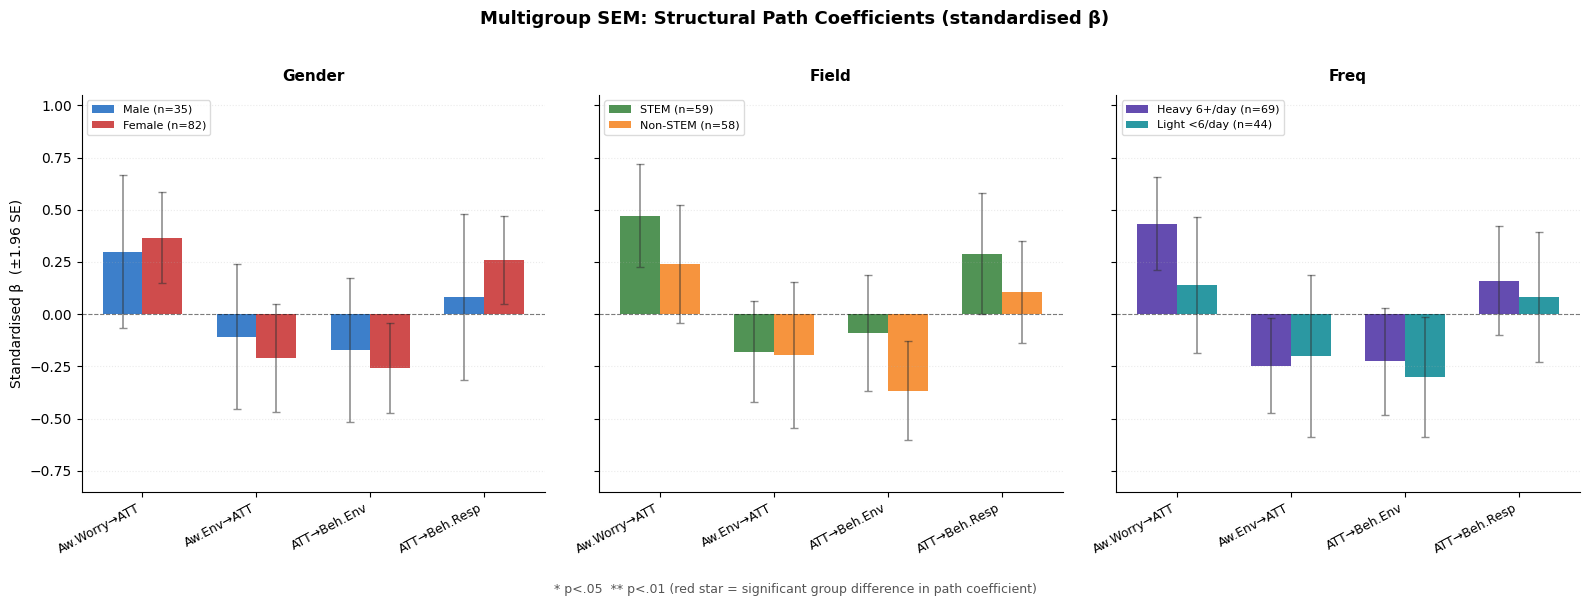

Saved -> output/tables/multigroup_chart_20260609.png


In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

GRP_COLORS = {
    'Gender': ['#1565C0', '#C62828'],    # blue / red
    'Field':  ['#2E7D32', '#F57F17'],    # green / amber
    'Freq':   ['#4527A0', '#00838F'],    # purple / teal
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
fig.suptitle('Multigroup SEM: Structural Path Coefficients (standardised β)',
             fontsize=13, fontweight='bold', y=1.02)

x = np.arange(len(PATH_KEYS))
w = 0.35

for ax, (grp_var, path_dicts) in zip(axes, mg_results.items()):
    lbls  = list(path_dicts.keys())
    clrs  = GRP_COLORS[grp_var]
    ns    = GRP_NS[grp_var]

    # Draw bars for each subgroup
    for ki, lbl in enumerate(lbls):
        betas = [path_dicts[lbl].get(pk, {}).get('β (std)', 0.0) for pk in PATH_KEYS]
        ses   = [path_dicts[lbl].get(pk, {}).get('SE', 0.0)           for pk in PATH_KEYS]
        off   = (ki - 0.5) * w
        ax.bar(x + off, betas, w,
               label='{} (n={})'.format(lbl, ns[lbl]),
               color=clrs[ki], alpha=0.83,
               yerr=[1.96 * s for s in ses], capsize=3,
               error_kw=dict(elinewidth=1.2, ecolor='#333333', alpha=0.55))

    # Significance markers above pairs with p_diff < .05
    for xi, pl in enumerate(PATH_LBLS):
        row = mg_save_df[(mg_save_df['Group Variable'] == grp_var) & (mg_save_df['Path'] == pl)]
        if row.empty:
            continue
        p_d = row.iloc[0]['p_diff']
        if p_d < 0.05:
            sig_txt = '**' if p_d < 0.01 else '*'
            tops = [path_dicts[lbl].get(PATH_KEYS[xi], {}).get('β (std)', 0.0)
                    + 1.96 * path_dicts[lbl].get(PATH_KEYS[xi], {}).get('SE', 0.0)
                    for lbl in lbls]
            star_y = max(tops) + 0.06
            ax.text(xi, star_y, sig_txt, ha='center', va='bottom',
                    fontsize=14, color='#B71C1C', fontweight='bold')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(PATH_LBLS, rotation=28, ha='right', fontsize=9)
    ax.set_title(grp_var, fontweight='bold', fontsize=11, pad=10)
    if ax is axes[0]:
        ax.set_ylabel('Standardised β  (±1.96 SE)', fontsize=10)
    ax.legend(fontsize=8, loc='upper left', framealpha=0.7)
    ax.set_ylim(-0.85, 1.05)
    ax.grid(axis='y', alpha=0.25, linestyle=':')
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

fig.text(0.5, -0.04,
         '* p<.05  ** p<.01 (red star = significant group difference in path coefficient)',
         ha='center', fontsize=9, color='#555555')

plt.tight_layout()
plt.savefig('../output/tables/multigroup_chart_{}.png'.format(DATE), dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> output/tables/multigroup_chart_{}.png'.format(DATE))

---
## 8. SEM Path Diagram

Visual summary of the structural model with standardised path coefficients (β), significance stars, and R² for each endogenous construct.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

FIG_W, FIG_H = 14, 7
BW, BH = 2.7, 1.0

NODES = {
    'Awareness\n(Worry)':      (2.2, 5.5),
    'Awareness\n(Env)':        (2.2, 1.5),
    'Attitude':                (7.0, 3.5),
    'Beh\nEnvironmental':      (11.8, 5.5),
    'Beh\nResponsible':        (11.8, 1.5),
}

NAME_MAP = {
    'Awareness_Worry':   'Awareness\n(Worry)',
    'Awareness_Env':     'Awareness\n(Env)',
    'Attitude':          'Attitude',
    'Beh_Environmental': 'Beh\nEnvironmental',
    'Beh_Responsible':   'Beh\nResponsible',
}

# Dynamic: read from sem_path_df (uses bootstrap p)
PATHS = [
    (NAME_MAP[r['Predictor']], NAME_MAP[r['Outcome']],
     r['β (std)'], r['p (boot)'])
    for _, r in sem_path_df.iterrows()
]

R2_VALS = {}
seen = set()
for _, r in sem_path_df.iterrows():
    key = NAME_MAP[r['Outcome']]
    if key not in seen:
        R2_VALS[key] = r['R²']
        seen.add(key)

COLORS = {
    'Awareness\n(Worry)': ('#DDEEFF', '#1565C0'),
    'Awareness\n(Env)':   ('#DDEEFF', '#1565C0'),
    'Attitude':           ('#D6EAD6', '#2E7D32'),
    'Beh\nEnvironmental': ('#FFF0DB', '#E65100'),
    'Beh\nResponsible':   ('#FFF0DB', '#E65100'),
}

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '†'
    return 'ns'

def box_edge_pt(cx, cy, tx, ty, hw, hh):
    dx, dy = tx - cx, ty - cy
    if dx == 0 and dy == 0:
        return cx, cy
    t_x = hw / abs(dx) if dx != 0 else float('inf')
    t_y = hh / abs(dy) if dy != 0 else float('inf')
    return cx + dx * min(t_x, t_y), cy + dy * min(t_x, t_y)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.set_xlim(0, FIG_W)
ax.set_ylim(0, FIG_H)
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

for src, dst, beta, p_val in PATHS:
    sx, sy = NODES[src]
    dx, dy = NODES[dst]
    x0, y0 = box_edge_pt(sx, sy, dx, dy, BW/2, BH/2)
    x1, y1 = box_edge_pt(dx, dy, sx, sy, BW/2, BH/2)
    is_sig = p_val < 0.05
    color  = '#1A1A1A' if is_sig else '#AAAAAA'
    lw     = 2.3 if is_sig else 1.7
    lstyle = 'solid' if is_sig else (0, (5, 3))
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='-|>', color=color, lw=lw,
                               linestyle=lstyle, mutation_scale=20,
                               connectionstyle='arc3,rad=0.0'), zorder=2)
    mid_x  = (x0 + x1) / 2
    mid_y  = (y0 + y1) / 2
    angle  = np.arctan2(y1 - y0, x1 - x0)
    off    = 0.46
    lx = mid_x - np.sin(angle) * off
    ly = mid_y + np.cos(angle) * off
    sign  = '+' if beta >= 0 else ''
    label = 'β = {}{:.3f}{}'.format(sign, beta, sig_stars(p_val))
    ax.text(lx, ly, label, ha='center', va='center', fontsize=10.5,
            color='#111111' if is_sig else '#888888', zorder=5,
            bbox=dict(boxstyle='round,pad=0.28', facecolor='white',
                      edgecolor='#CCCCCC', alpha=0.92, linewidth=0.8))

for name, (cx, cy) in NODES.items():
    fc, ec = COLORS[name]
    ax.add_patch(FancyBboxPatch((cx - BW/2, cy - BH/2), BW, BH,
                               boxstyle='round,pad=0.10',
                               facecolor=fc, edgecolor=ec, linewidth=2.4, zorder=3))
    lines = name.split('\n')
    if len(lines) == 1:
        ax.text(cx, cy, lines[0], ha='center', va='center',
                fontsize=11.5, fontweight='bold', zorder=4)
    else:
        ax.text(cx, cy + 0.19, lines[0], ha='center', va='center',
                fontsize=11.5, fontweight='bold', zorder=4)
        ax.text(cx, cy - 0.19, lines[1], ha='center', va='center',
                fontsize=11.5, fontweight='bold', zorder=4)
    if name in R2_VALS:
        ax.text(cx, cy - BH/2 - 0.28, 'R² = {:.3f}'.format(R2_VALS[name]),
                ha='center', va='top', fontsize=9.5,
                color='#444444', style='italic', zorder=4)

legend_handles = [
    mpatches.Patch(facecolor='#DDEEFF', edgecolor='#1565C0', lw=1.5,
                   label='Predictors (Awareness)'),
    mpatches.Patch(facecolor='#D6EAD6', edgecolor='#2E7D32', lw=1.5,
                   label='Mediator (Attitude)'),
    mpatches.Patch(facecolor='#FFF0DB', edgecolor='#E65100', lw=1.5,
                   label='Outcomes (Behavior)'),
    mpatches.Patch(facecolor='none', edgecolor='none', label=''),
    plt.Line2D([0],[0], color='#1A1A1A', lw=2.3, label='Significant (p < .05)'),
    plt.Line2D([0],[0], color='#AAAAAA', lw=1.7, linestyle=(0,(5,3)),
               label='Marginal (p < .10)'),
]
ax.legend(handles=legend_handles, loc='lower center',
          bbox_to_anchor=(0.5, -0.01), ncol=6,
          fontsize=9, framealpha=0.95, edgecolor='#CCCCCC')

ax.text(0.995, 0.995,
        '*** p < .001   ** p < .01   * p < .05   † p < .10',
        transform=ax.transAxes, ha='right', va='top', fontsize=9, color='#555555',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#DDDDDD', alpha=0.92))

ax.text(0.5, 1.025,
        'PLS-SEM — AI Use Survey (N = 117)',
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=13, fontweight='bold')
ax.text(0.5, 0.997,
        'NIPALS centroid scheme • OLS paths + bootstrap 95% CI (B=1000)',
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=8.8, color='#666666')

plt.tight_layout(pad=0.6)
out = '../output/figures/sem_diagram_{}.png'.format(DATE)
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('Saved ->', out)


## Section 9. Item-Level Simple Regressions

Simple OLS regressions of individual survey items against dependent-construct Bartlett factor scores (from Section 5).

**Note on BEH validity.** Convergent and discriminant validity for `Beh_Environmental` and `Beh_Responsible` are unchanged from Sections 2-3 - same items, same sample. No recomputation needed.

| Step | IVs | DVs |
|---|---|---|
| **9a** | Each `aw_*` item (6 items) | Attitude, Beh_Environmental, Beh_Responsible |
| **9b** | Each `att_*` item (3 items; `att_skill_worry` reverse-coded) | Beh_Environmental, Beh_Responsible |

Each regression is simple (one predictor at a time). For simple regression beta (std) = Pearson *r* and R2 = r2.

In [33]:
# Section 9: Item-level simple regressions
# Requires: CONSTRUCTS, prep(), factor_scores, ols_path, DATE  (all from Section 5)

AW_ITEMS  = ['aw_error', 'aw_ethics', 'aw_privacy', 'aw_deepfake',
             'aw_env_dc', 'aw_env_use']
ATT_ITEMS = ['att_pos', 'att_easy', 'att_skill_worry']

iv_df    = prep(AW_ITEMS + ATT_ITEMS).reset_index(drop=True)
fs_df    = factor_scores.reset_index(drop=True)
reg_data = pd.concat([iv_df, fs_df], axis=1)

beta_key = 'β (std)'
r2_key   = 'R²'

HDR = ('  {:<22} {:<22} {:>6} {:>7} {:>7} {:>7} {:>7} {:>6}'.format(
       'Item', 'DV', 'beta', 'B', 'SE', 't', 'p', 'R2'))
SEP = '  ' + '-' * 82

ITEM_LABELS_9 = {
    'aw_error':       'AI error risk',
    'aw_ethics':      'AI ethics risk',
    'aw_privacy':     'AI privacy risk',
    'aw_deepfake':    'Deepfake risk',
    'aw_env_dc':      'Data-centre energy',
    'aw_env_use':     'Cumulative AI energy',
    'att_pos':        'Positive attitude',
    'att_easy':       'Ease of use',
    'att_skill_worry':'Skill worry (R)',
}

def sig_tag(p):
    return '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''

def print_row(r):
    print('  {:<22} {:<22} {:>6.3f} {:>7.3f} {:>7.3f} {:>7.3f} {:>7.4f} {:>6.3f}  {}'.format(
        r['Predictor'], r['Outcome'], r[beta_key], r['B (unstd)'],
        r['SE'], r['t'], r['p'], r[r2_key], sig_tag(r['p'])))

all_rows = []

print('9a. Awareness items -> Attitude / Beh_Environmental / Beh_Responsible')
print(HDR)
print(SEP)
for item in AW_ITEMS:
    for dv in ['Attitude', 'Beh_Environmental', 'Beh_Responsible']:
        r = ols_path(dv, [item], reg_data)[0]
        all_rows.append(r)
        print_row(r)
    print()

print('9b. Attitude items -> Beh_Environmental / Beh_Responsible')
print(HDR)
print(SEP)
for item in ATT_ITEMS:
    for dv in ['Beh_Environmental', 'Beh_Responsible']:
        r = ols_path(dv, [item], reg_data)[0]
        all_rows.append(r)
        print_row(r)
    print()

print('* p<.05  ** p<.01  *** p<.001')

item_reg_df = pd.DataFrame(all_rows)
item_reg_df['Item Label'] = item_reg_df['Predictor'].map(ITEM_LABELS_9)
item_reg_df['Sig'] = item_reg_df['p'].apply(sig_tag)
cols_out = ['Predictor', 'Item Label', 'Outcome', beta_key, 'B (unstd)', 'SE', 't', 'p', r2_key, 'Adj.R²', 'Sig']
item_reg_df = item_reg_df[cols_out]

# Save CSV
csv_path  = f'../output/tables/item_regressions_{DATE}.csv'
item_reg_df.to_csv(csv_path, index=False)

# Save Excel (two sheets: 9a awareness, 9b attitude)
xlsx_path = f'../output/tables/item_regressions_{DATE}.xlsx'
with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
    aw_mask  = item_reg_df['Predictor'].isin(AW_ITEMS)
    item_reg_df[aw_mask].to_excel(writer, sheet_name='9a_Awareness', index=False)
    item_reg_df[~aw_mask].to_excel(writer, sheet_name='9b_Attitude', index=False)
    item_reg_df.to_excel(writer, sheet_name='All', index=False)

print(f'Saved CSV  -> {csv_path}')
print(f'Saved XLSX -> {xlsx_path}')

9a. Awareness items -> Attitude / Beh_Environmental / Beh_Responsible
  Item                   DV                       beta       B      SE       t       p     R2
  ----------------------------------------------------------------------------------
  aw_error               Attitude                0.176   0.533   0.278   1.921  0.0572  0.031  
  aw_error               Beh_Environmental       0.113   0.347   0.284   1.221  0.2246  0.013  
  aw_error               Beh_Responsible         0.346   1.087   0.275   3.952  0.0001  0.120  ***

  aw_ethics              Attitude                0.367   0.693   0.164   4.236  0.0000  0.135  ***
  aw_ethics              Beh_Environmental       0.105   0.201   0.177   1.131  0.2605  0.011  
  aw_ethics              Beh_Responsible         0.386   0.757   0.169   4.493  0.0000  0.149  ***

  aw_privacy             Attitude                0.096   0.165   0.160   1.031  0.3047  0.009  
  aw_privacy             Beh_Environmental       0.194   0.341   0.1

---
## Section 10. SHAP Analysis

Gradient Boosting + TreeSHAP to quantify which survey items most drive each outcome factor score.

Adapted from the EPR-SHAP framework (tongkyu-kim/EPR-SHAP): PermutationExplainer replaced by **TreeSHAP** (`shap.TreeExplainer`) since `GradientBoostingRegressor` supports it natively.

| Model | Features (IVs) | Outcome (DV) |
|---|---|---|
| **M1** | 6 awareness items | Attitude factor score |
| **M2** | 6 awareness + 3 attitude items | Beh_Environmental factor score |
| **M3** | 6 awareness + 3 attitude items | Beh_Responsible factor score |

Model fit reported as 5-fold CV R². Outputs:
- `output/figures/shap_importance_DATE.png` — cross-outcome grouped bar chart
- `output/figures/shap_beeswarm_{DV}_DATE.png` — beeswarm per outcome
- `output/tables/shap_importance_DATE.xlsx` — mean |SHAP| table + model fit

In [ ]:
# Section 10: SHAP Analysis
# Requires: factor_scores, prep(), DATE  (from Section 5)
# pip install shap scikit-learn

import shap
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

AW_ITEMS_10  = ['aw_error', 'aw_ethics', 'aw_privacy', 'aw_deepfake',
                'aw_env_dc', 'aw_env_use']
ATT_ITEMS_10 = ['att_pos', 'att_easy', 'att_skill_worry']

ITEM_LABELS_10 = {
    'aw_error':        'AI error risk',
    'aw_ethics':       'AI ethics risk',
    'aw_privacy':      'AI privacy risk',
    'aw_deepfake':     'Deepfake risk',
    'aw_env_dc':       'Data-centre energy',
    'aw_env_use':      'Cumulative AI energy',
    'att_pos':         'Positive attitude',
    'att_easy':        'Ease of use',
    'att_skill_worry': 'Skill worry (R)',
}

MODELS_10 = {
    'Attitude':          AW_ITEMS_10,
    'Beh_Environmental': AW_ITEMS_10 + ATT_ITEMS_10,
    'Beh_Responsible':   AW_ITEMS_10 + ATT_ITEMS_10,
}

iv_df_10 = prep(AW_ITEMS_10 + ATT_ITEMS_10).reset_index(drop=True)
fs_df_10 = factor_scores.reset_index(drop=True)

fitted_10  = {}
sv_dict_10 = {}
r2_dict_10 = {}

print('Training GBM + computing TreeSHAP...')
for dv, features in MODELS_10.items():
    labels = [ITEM_LABELS_10[f] for f in features]
    X = pd.DataFrame(iv_df_10[features].values, columns=labels)
    y = fs_df_10[dv].values

    gbm = GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                    learning_rate=0.05, subsample=0.8,
                                    random_state=42)
    gbm.fit(X, y)
    fitted_10[dv] = gbm

    cv_r2 = cross_val_score(gbm, X, y, cv=5, scoring='r2').mean()
    r2_dict_10[dv] = round(float(cv_r2), 3)
    print(f'  {dv:<22}  CV R² (5-fold) = {cv_r2:.3f}')

    explainer = shap.TreeExplainer(gbm)
    sv_dict_10[dv] = explainer(X)

print()

# ── Importance table ────────────────────────────────────────────────────────
imp_rows_10 = []
for dv, sv in sv_dict_10.items():
    mean_abs = np.abs(sv.values).mean(axis=0)
    for feat, val in zip(sv.feature_names, mean_abs):
        imp_rows_10.append({'Label': feat, 'Outcome': dv, 'Mean |SHAP|': round(val, 4)})
imp_df_10 = pd.DataFrame(imp_rows_10)

# ── Cross-outcome grouped bar chart (EPR-SHAP style) ───────────────────────
ALL_LABELS_ORD = (imp_df_10[imp_df_10['Outcome'] == 'Beh_Responsible']
                  .sort_values('Mean |SHAP|', ascending=False)['Label'].tolist())

fig, ax = plt.subplots(figsize=(12, 5))
clrs_10 = ['#1565C0', '#2E7D32', '#C62828']
w10 = 0.26
x10 = np.arange(len(ALL_LABELS_ORD))

for idx, (dv, clr) in enumerate(zip(MODELS_10.keys(), clrs_10)):
    sub = imp_df_10[imp_df_10['Outcome'] == dv].set_index('Label')
    vals = [sub.loc[lbl, 'Mean |SHAP|'] if lbl in sub.index else 0.0
            for lbl in ALL_LABELS_ORD]
    ax.bar(x10 + idx * w10, vals, w10,
           label=f'{dv}  (CV R²={r2_dict_10[dv]})', color=clr, alpha=0.82)

ax.set_xticks(x10 + w10)
ax.set_xticklabels(ALL_LABELS_ORD, rotation=32, ha='right', fontsize=9)
ax.set_ylabel('Mean |SHAP value|', fontsize=10)
ax.set_title('SHAP Feature Importance — AI Use Survey  (N = 117)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
shap_bar_path = f'../output/figures/shap_importance_{DATE}.png'
plt.savefig(shap_bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {shap_bar_path}')

# ── Beeswarm per outcome ────────────────────────────────────────────────────
for dv, sv in sv_dict_10.items():
    plt.figure()
    shap.plots.beeswarm(sv, max_display=len(sv.feature_names), show=False)
    plt.title(f'SHAP Beeswarm: {dv}  (CV R²={r2_dict_10[dv]})',
              fontsize=11, pad=14)
    bee_path = f'../output/figures/shap_beeswarm_{dv}_{DATE}.png'
    plt.savefig(bee_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {bee_path}')

# ── Save to Excel ───────────────────────────────────────────────────────────
shap_xlsx = f'../output/tables/shap_importance_{DATE}.xlsx'
with pd.ExcelWriter(shap_xlsx, engine='openpyxl') as writer:
    imp_df_10.to_excel(writer, sheet_name='Mean_SHAP', index=False)
    pd.DataFrame([{'Outcome': k, 'CV_R2_5fold': v}
                  for k, v in r2_dict_10.items()]).to_excel(
        writer, sheet_name='Model_Fit', index=False)
print(f'Saved -> {shap_xlsx}')